-----
Nama : Nadine Putri Larasati  
Ruang : 214
-----

-----
Analisis Big Mac Index Untuk Mengidentifikasi Potensi Pasar dan Strategi Pricing Dalam Bisnis Internasional
-----

Tableau Dashboard:

https://public.tableau.com/views/big_mac_dashboard/ObjectiveAnalysis1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

-----------
Berdasarkan Big Mac Index Dataset, sebagai owner saya akan memanfaatkan data ini untuk memahami peluang profit dan pengambilan keputusan bisnis internasional melalui analisis purchasing power parity (PPP) dan perbandingan daya beli antar negara. Perbedaan harga Big Mac di setiap negara menunjukkan adanya variasi nilai mata uang, tingkat biaya hidup, serta kemampuan konsumsi masyarakat yang dapat memengaruhi strategi bisnis global. Nilai tukar mata uang yang terlalu tinggi atau terlalu rendah dibandingkan nilai sebenarnya dapat berdampak pada penentuan harga produk, biaya operasional, hingga potensi keuntungan perusahaan di suatu negara. Selain itu, tanpa analisis yang tepat terhadap kondisi ekonomi dan daya beli masyarakat, perusahaan berisiko menetapkan strategi pricing maupun ekspansi pasar yang kurang optimal sehingga profit yang dihasilkan tidak maksimal. Melalui analisis data ini, saya menargetkan untuk mengidentifikasi negara dengan potensi pasar terbaik, memahami pengaruh nilai tukar terhadap daya beli konsumen, serta menentukan strategi bisnis internasional yang lebih menguntungkan dan efisien.

1. Objective Analysis 1 : Menganalisis negara dengan nilai mata uang paling overvalued dan undervalued berdasarkan Big Mac Index untuk menentukan peluang strategi pricing yang lebih optimal
2. Objective Analysis 2 : Menganalisis hubungan antara local_price dan dollar_price untuk memahami perbedaan daya beli masyarakat antar negara
3. Objective Analysis 3 : Menganalisis perbandingan nilai tukar aktual (dollar_ex) dan nilai PPP untuk mengidentifikasi negara dengan potensi pasar yang lebih menguntungkan
4. Objective Analysis 4 : Menganalisis distribusi harga Big Mac antar negara dan periode waktu tertentu untuk memahami perubahan biaya hidup dan potensi konsumsi global
-----------

## 1. Data Loading

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from scipy.stats import zscore
from scipy.stats import kruskal

In [2]:
df = pd.read_csv('big_mac.csv')

## 2. Data Wrangling

### 2.1 Data Gathering

In [3]:
df.head()

,date,iso_a3,currency_code,name,local_price,dollar_ex,dollar_price,USD_raw,EUR_raw,GBP_raw,JPY_raw,CNY_raw,GDP_dollar,adj_price,USD_adjusted,EUR_adjusted,GBP_adjusted,JPY_adjusted,CNY_adjusted
0,2000-04-01,ARG,ARS,Argentina,2.50,1.00,2.500000,-0.00398,0.05007,-0.16722,-0.09864,1.09091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-04-01,AUS,AUD,Australia,2.59,1.68,1.541667,-0.38579,-0.35246,-0.48645,-0.44416,0.28939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-04-01,BRA,BRL,Brazil,2.95,1.79,1.648045,-0.34341,-0.30778,-0.45102,-0.40581,0.37836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-04-01,CAN,CAD,Canada,2.85,1.47,1.938776,-0.22758,-0.18566,-0.35417,-0.30099,0.62152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-04-01,CHE,CHF,Switzerland,5.90,1.70,3.470588,0.38270,0.45774,0.15609,0.25130,1.90267,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1386 non-null   object 
 1   iso_a3         1386 non-null   object 
 2   currency_code  1386 non-null   object 
 3   name           1386 non-null   object 
 4   local_price    1386 non-null   float64
 5   dollar_ex      1386 non-null   float64
 6   dollar_price   1386 non-null   float64
 7   USD_raw        1386 non-null   float64
 8   EUR_raw        1386 non-null   float64
 9   GBP_raw        1386 non-null   float64
 10  JPY_raw        1386 non-null   float64
 11  CNY_raw        1386 non-null   float64
 12  GDP_dollar     702 non-null    float64
 13  adj_price      702 non-null    float64
 14  USD_adjusted   702 non-null    float64
 15  EUR_adjusted   702 non-null    float64
 16  GBP_adjusted   702 non-null    float64
 17  JPY_adjusted   702 non-null    float64
 18  CNY_adju

In [5]:
df.shape

(1386, 19)

### 2.2 Data Assessing

In [6]:
df.isna().sum()

date               0
iso_a3             0
currency_code      0
name               0
local_price        0
dollar_ex          0
dollar_price       0
USD_raw            0
EUR_raw            0
GBP_raw            0
JPY_raw            0
CNY_raw            0
GDP_dollar       684
adj_price        684
USD_adjusted     684
EUR_adjusted     684
GBP_adjusted     684
JPY_adjusted     684
CNY_adjusted     684
dtype: int64

In [7]:
df.duplicated().sum()

0

### 2.3 Data Cleaning

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
missing_cols = [
    'GDP_dollar',
    'adj_price',
    'USD_adjusted',
    'EUR_adjusted',
    'GBP_adjusted',
    'JPY_adjusted',
    'CNY_adjusted'
]

# imputasi menggunakan median
for col in missing_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [10]:
df.isna().sum()

date             0
iso_a3           0
currency_code    0
name             0
local_price      0
dollar_ex        0
dollar_price     0
USD_raw          0
EUR_raw          0
GBP_raw          0
JPY_raw          0
CNY_raw          0
GDP_dollar       0
adj_price        0
USD_adjusted     0
EUR_adjusted     0
GBP_adjusted     0
JPY_adjusted     0
CNY_adjusted     0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1386 non-null   datetime64[ns]
 1   iso_a3         1386 non-null   object        
 2   currency_code  1386 non-null   object        
 3   name           1386 non-null   object        
 4   local_price    1386 non-null   float64       
 5   dollar_ex      1386 non-null   float64       
 6   dollar_price   1386 non-null   float64       
 7   USD_raw        1386 non-null   float64       
 8   EUR_raw        1386 non-null   float64       
 9   GBP_raw        1386 non-null   float64       
 10  JPY_raw        1386 non-null   float64       
 11  CNY_raw        1386 non-null   float64       
 12  GDP_dollar     1386 non-null   float64       
 13  adj_price      1386 non-null   float64       
 14  USD_adjusted   1386 non-null   float64       
 15  EUR_adjusted   1386 n

## 3. Exploratory Data Analysis (EDA)

### 3.1 Objective Analysis 1: Menganalisis negara dengan nilai mata uang paling overvalued dan undervalued berdasarkan Big Mac Index untuk menentukan peluang strategi pricing yang lebih optimal

In [12]:
latest_date = df['date'].max()
latest_df = df[df['date'] == latest_date]

# Sorting berdasarkan USD_raw
overvalued = latest_df.sort_values(by='USD_raw', ascending=False).head(10)
undervalued = latest_df.sort_values(by='USD_raw', ascending=True).head(10)

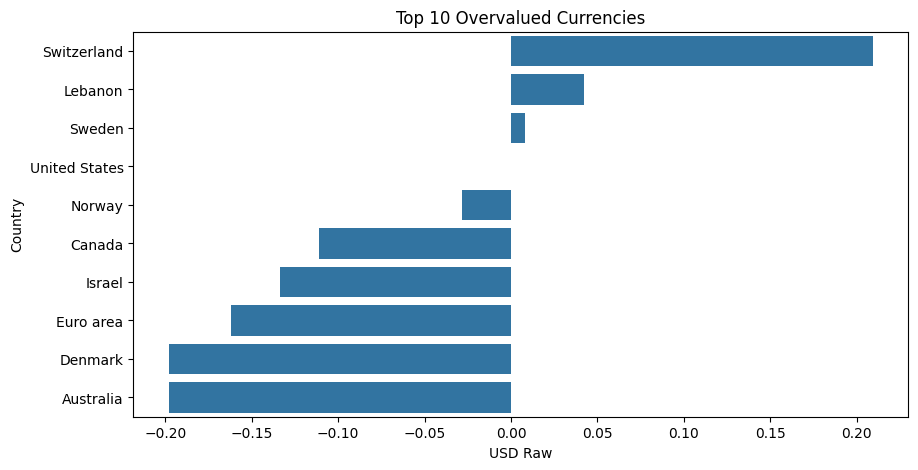

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(data=overvalued, x='USD_raw', y='name')
plt.title('Top 10 Overvalued Currencies')
plt.xlabel('USD Raw')
plt.ylabel('Country')
plt.show()

### Explanatory Analysis 1:

Berdasarkan visualisasi Top 10 Overvalued Currencies, negara seperti Switzerland, Lebanon, Sweden menunjukkan nilai mata uang yang relatif lebih tinggi dibandingkan nilai tukar aktualnya berdasarkan pendekatan Big Mac Index. Hal ini menunjukkan bahwa harga Big Mac di negara-negara tersebut cenderung lebih mahal dibandingkan daya beli standar internasional. Kondisi tersebut mengindikasikan biaya hidup dan biaya operasional yang tinggi sehingga strategi bisnis di negara dengan mata uang overvalued perlu lebih berhati-hati dalam menentukan pricing dan efisiensi biaya. Meskipun daya beli masyarakat di negara-negara tersebut relatif kuat, perusahaan harus mempertimbangkan margin keuntungan karena tingginya biaya produksi dan operasional dapat mengurangi profitabilitas.

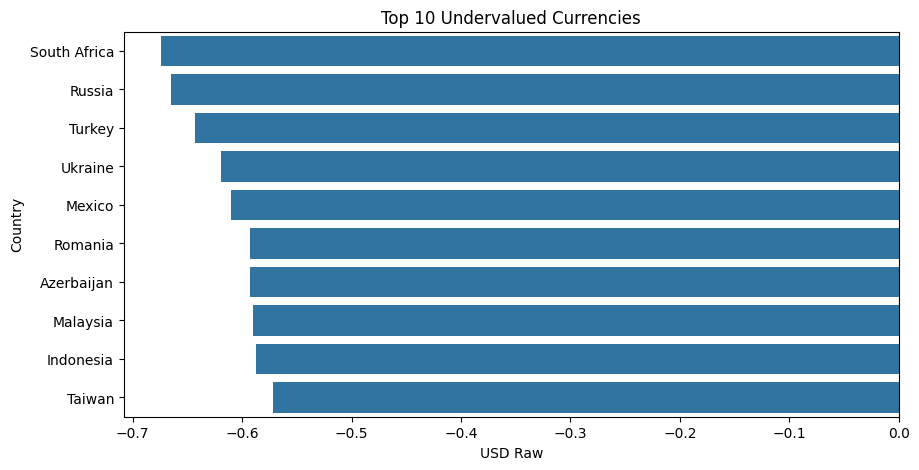

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=undervalued, x='USD_raw', y='name')
plt.title('Top 10 Undervalued Currencies')
plt.xlabel('USD Raw')
plt.ylabel('Country')
plt.show()

### Explanatory Analysis 2:

Pada visualisasi Top 10 Undervalued Currencies, negara seperti South Africa, Russia, Turkey, Ukraine, Mexico, Malaysia, Indonesia, dan Taiwan menunjukkan nilai mata uang yang jauh lebih rendah dibandingkan nilai PPP. Hal ini mengindikasikan bahwa harga produk relatif lebih murah dibandingkan standar global sehingga negara-negara tersebut berpotensi menjadi pasar yang menarik untuk efisiensi biaya operasional maupun strategi ekspansi bisnis. Negara dengan mata uang undervalued juga dapat memberikan peluang profit lebih tinggi bagi perusahaan internasional karena biaya produksi, tenaga kerja, maupun operasional cenderung lebih rendah. Namun, perusahaan tetap perlu memperhatikan stabilitas ekonomi dan risiko inflasi di negara-negara tersebut sebelum melakukan investasi atau ekspansi pasar.

### 3.2 Objective Analysis 2: Menganalisis hubungan antara local_price dan dollar_price untuk memahami perbedaan daya beli masyarakat antar negara

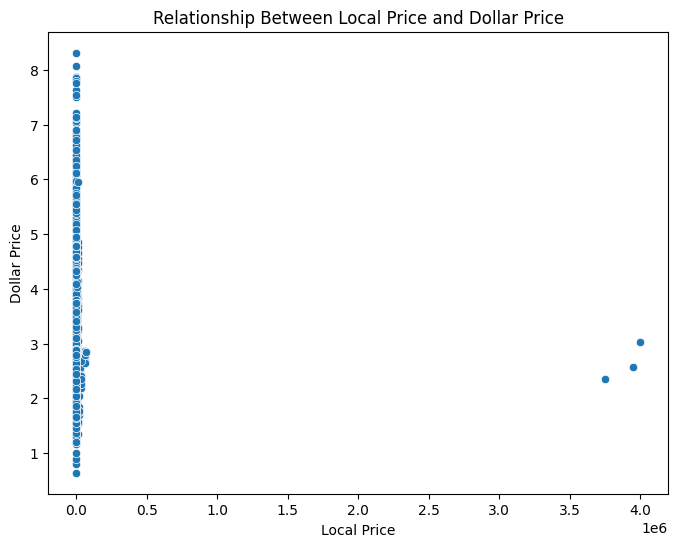

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='local_price',
    y='dollar_price'
)

plt.title('Relationship Between Local Price and Dollar Price')
plt.xlabel('Local Price')
plt.ylabel('Dollar Price')
plt.show()

In [16]:
correlation = df[['local_price', 'dollar_price']].corr()

print(correlation)

              local_price  dollar_price
local_price      1.000000     -0.025282
dollar_price    -0.025282      1.000000


### Explanatory Analysis 1:

Berdasarkan visualisasi Relationship Between Local Price and Dollar Price, persebaran data terlihat tidak membentuk pola hubungan yang kuat dan cenderung menyebar secara acak. Hal tersebut diperkuat dengan hasil korelasi sebesar -0.025282 yang menunjukkan hubungan negatif sangat lemah atau hampir tidak memiliki hubungan linear antara local_price dan dollar_price.

Kondisi ini menunjukkan bahwa harga Big Mac dalam mata uang lokal tidak secara langsung menentukan harga dalam dollar karena adanya pengaruh besar dari nilai tukar masing-masing negara. Dengan kata lain, negara yang memiliki harga lokal tinggi belum tentu memiliki harga dalam dollar yang tinggi pula. Hal ini mengindikasikan bahwa daya beli masyarakat dan kekuatan mata uang memiliki pengaruh yang lebih besar dibandingkan nominal harga lokal itu sendiri.

Dari sisi bisnis internasional, insight ini penting karena perusahaan tidak dapat hanya mengandalkan harga lokal dalam menentukan strategi pasar global. Perusahaan perlu mempertimbangkan stabilitas nilai tukar dan purchasing power masyarakat agar strategi pricing lebih optimal serta mampu menghasilkan profit yang lebih efisien di tiap negara.

### 3.3 Objective Analysis 3: Menganalisis perbandingan nilai tukar aktual (dollar_ex) dan nilai PPP untuk mengidentifikasi negara dengan potensi pasar yang lebih menguntungkan

In [17]:
# Menghitung PPP sederhana
df['PPP'] = df['local_price'] / df['dollar_price']

latest_df = df[df['date'] == latest_date]
sample_df = latest_df[['name', 'dollar_ex', 'PPP']].head(15)

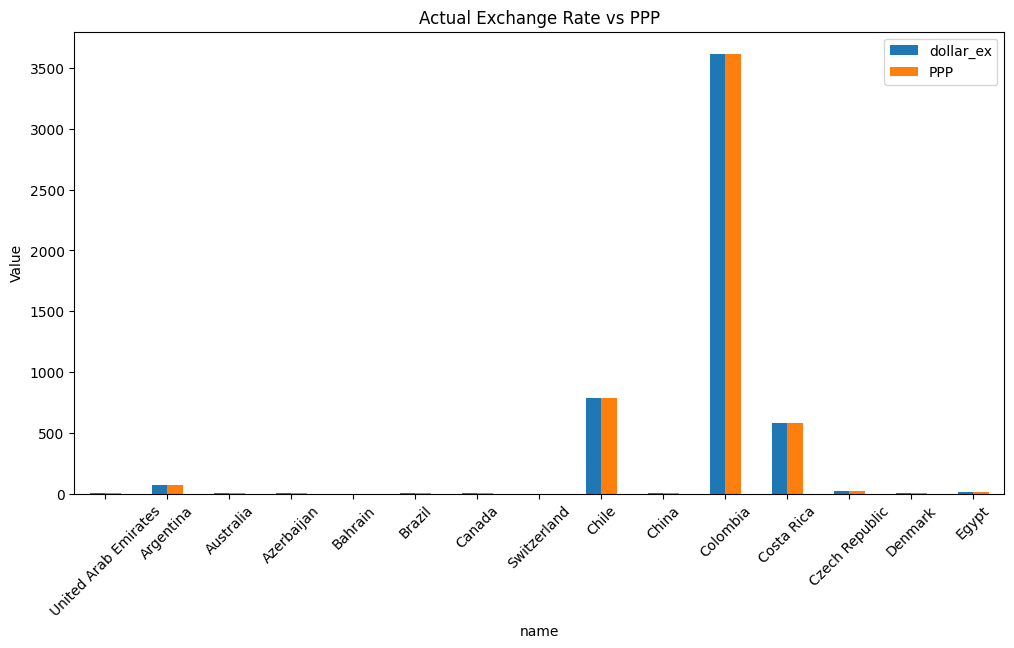

In [18]:
sample_df.set_index('name')[['dollar_ex', 'PPP']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Actual Exchange Rate vs PPP')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

### Explanatory Analysis 1:

Berdasarkan visualisasi Actual Exchange Rate vs PPP, sebagian besar negara memiliki nilai yang relatif mendekati nol, sedangkan Costa Rica, Chile, dan terutama Colombia menunjukkan perbedaan yang sangat besar dibandingkan negara lainnya. Colombia memiliki nilai tertinggi hingga sekitar 3600, diikuti Chile sekitar 800 dan Costa Rica sekitar 600.

Perbedaan yang sangat tinggi tersebut menunjukkan adanya ketidaksesuaian signifikan antara nilai tukar aktual dan nilai tukar berdasarkan PPP. Hal ini mengindikasikan bahwa mata uang di negara-negara tersebut kemungkinan mengalami undervaluation yang cukup besar dibandingkan nilai ekonomi sebenarnya berdasarkan daya beli masyarakat.

Dari perspektif bisnis, negara dengan gap besar antara exchange rate dan PPP dapat menjadi peluang untuk memperoleh efisiensi biaya operasional maupun keuntungan ekspor karena biaya relatif lebih murah dalam nilai dollar. Namun, kondisi tersebut juga dapat menunjukkan ketidakstabilan ekonomi atau fluktuasi mata uang yang tinggi sehingga perusahaan perlu mempertimbangkan risiko kurs sebelum melakukan investasi atau ekspansi pasar internasional.

### 3.4 Objective Analysis 4: Menganalisis distribusi harga Big Mac antar negara dan periode waktu tertentu untuk memahami perubahan biaya hidup dan potensi konsumsi global

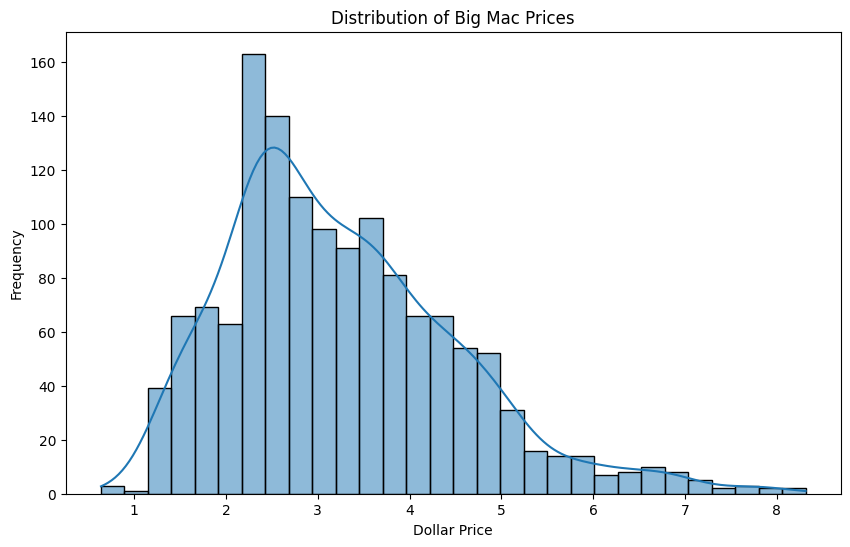

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='dollar_price',
    bins=30,
    kde=True
)

plt.title('Distribution of Big Mac Prices')
plt.xlabel('Dollar Price')
plt.ylabel('Frequency')
plt.show()

### Explanatory Analysis 1:

Berdasarkan visualisasi Distribution of Big Mac Prices, frekuensi tertinggi berada pada kisaran dollar price 2.3 hingga 2.5. Hal ini menunjukkan bahwa sebagian besar negara memiliki harga Big Mac pada rentang tersebut sehingga dapat dianggap sebagai kisaran harga global yang paling umum dan relatif stabil. Sementara itu, harga di luar rentang tersebut menunjukkan adanya perbedaan daya beli, biaya hidup, dan kondisi ekonomi antar negara yang cukup signifikan.

Distribusi harga yang bervariasi juga menunjukkan adanya ketimpangan purchasing power antar negara. Negara dengan harga Big Mac lebih tinggi cenderung memiliki biaya hidup dan tingkat pendapatan masyarakat yang lebih tinggi, sedangkan negara dengan harga lebih rendah dapat menjadi pasar potensial untuk efisiensi biaya maupun strategi penetrasi pasar dengan harga kompetitif.

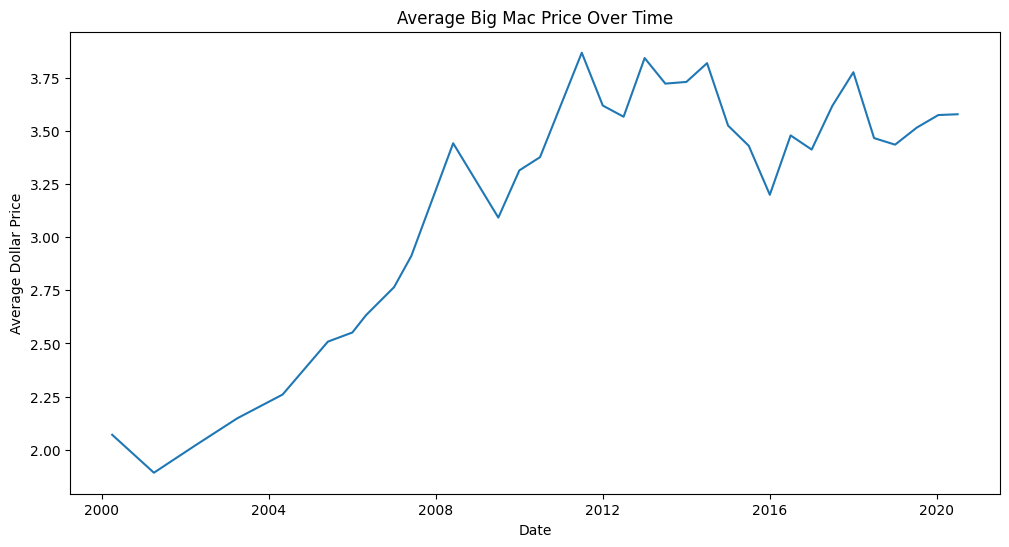

In [20]:
trend_df = df.groupby('date')['dollar_price'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=trend_df,
    x='date',
    y='dollar_price'
)

plt.title('Average Big Mac Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Dollar Price')
plt.show()

### Explanatory Analysis 2:

Pada visualisasi Average Big Mac Price Over Time, terlihat bahwa harga rata-rata Big Mac masih relatif rendah pada periode 2000–2004, kemudian mengalami kenaikan signifikan pada tahun 2008, dan setelah itu berfluktuasi hingga tahun 2020. Kenaikan drastis pada tahun 2008 kemungkinan dipengaruhi oleh kondisi ekonomi global seperti inflasi dan krisis finansial internasional yang berdampak pada harga barang dan nilai tukar mata uang.

Bagi perusahaan internasional, perubahan harga dari waktu ke waktu menunjukkan bahwa strategi bisnis global harus mampu beradaptasi terhadap perubahan ekonomi dunia. Perusahaan perlu memperhatikan tren inflasi, perubahan kurs mata uang, dan daya beli masyarakat agar strategi pricing dan ekspansi pasar tetap kompetitif serta mampu menghasilkan profit yang optimal dalam jangka panjang.

## 4. Descriptive Analysis

### 4.1 Skewness

perbaiki kode sesuai kode dari dosen untuk menentukan apakah distribusi normal (ambil moderat skewness). jika nilai skewness range moderat + distribusi normal

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns

skew_df = pd.DataFrame({
    'Column': numeric_cols,
    'Skewness': [df[col].skew() for col in numeric_cols]
})

def interpret_skewness(skew):
    if -0.5 <= skew <= 0.5:
        return 'Mendekati Normal'
    elif -1 <= skew < -0.5 or 0.5 < skew <= 1:
        return 'Skewness Moderat'
    else:
        return 'Skewness Tinggi (Tidak Normal)'

skew_df['Interpretasi'] = skew_df['Skewness'].apply(interpret_skewness)

skew_df = skew_df.sort_values(by='Skewness', ascending=False)

skew_df

,Column,Skewness,Interpretasi
1,dollar_ex,21.590422,Skewness Tinggi (Tidak Normal)
15,PPP,21.590422,Skewness Tinggi (Tidak Normal)
0,local_price,21.421804,Skewness Tinggi (Tidak Normal)
9,adj_price,2.019539,Skewness Tinggi (Tidak Normal)
8,GDP_dollar,2.008788,Skewness Tinggi (Tidak Normal)
10,USD_adjusted,1.744310,Skewness Tinggi (Tidak Normal)
7,CNY_raw,1.596377,Skewness Tinggi (Tidak Normal)
14,CNY_adjusted,1.499509,Skewness Tinggi (Tidak Normal)
13,JPY_adjusted,1.347453,Skewness Tinggi (Tidak Normal)
3,USD_raw,1.340751,Skewness Tinggi (Tidak Normal)


Sebagian besar variabel memiliki nilai skewness lebih besar dari 1 sehingga termasuk kategori skewness tinggi (tidak normal). Hanya variabel GBP_raw, EUR_raw, dan dollar_price yang berada pada kategori skewness moderat sehingga distribusinya relatif lebih mendekati normal dibandingkan variabel lainnya. Namun, karena tidak ada variabel yang memiliki nilai skewness pada rentang -0,5 hingga 0,5, maka tidak terdapat variabel yang dapat dikategorikan berdistribusi normal berdasarkan kriteria skewness yang digunakan. Distribusi data pada dataset ini secara umum tidak normal dan cenderung ke arah kanan (positively skewed).

### 4.2 Metode Statistik

In [22]:
comparison_results = []

for col in numeric_cols:

    # Z-Score
    z_scores = np.abs(zscore(df[col]))
    z_outlier_count = (z_scores > 3).sum()

    # Tukey's Rule (IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    tukey_outlier_count = (
        ((df[col] < lower_bound) |
         (df[col] > upper_bound))
    ).sum()

    comparison_results.append({
        'Column': col,
        'Z-Score Outliers': z_outlier_count,
        'Tukey Rule Outliers': tukey_outlier_count
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Column,Z-Score Outliers,Tukey Rule Outliers
0,local_price,3,266
1,dollar_ex,3,243
2,dollar_price,14,32
3,USD_raw,24,46
4,EUR_raw,16,30
5,GBP_raw,18,30
6,JPY_raw,19,43
7,CNY_raw,28,48
8,GDP_dollar,34,648
9,adj_price,36,658


Berdasarkan hasil perbandingan, Tukey's Rule (IQR) mendeteksi outlier jauh lebih banyak dibandingkan Z-Score pada hampir seluruh variabel. Perbedaan ini terutama terlihat pada local_price, dollar_ex, GDP_dollar, dan berbagai kolom adjusted valuation. Hasil tersebut sejalan dengan analisis skewness yang menunjukkan bahwa sebagian besar variabel memiliki distribusi right-skewed dan tidak normal. Karena Z-Score bergantung pada mean dan standar deviasi, metode ini menjadi kurang sensitif terhadap data yang memiliki banyak nilai ekstrem. Sebaliknya, Tukey's Rule lebih sesuai karena lebih robust terhadap distribusi yang tidak normal. Oleh karena itu, Tukey's Rule (IQR) dipilih sebagai metode deteksi outlier pada Big Mac Index Dataset.

### 4.3 Handling Outlier

In [23]:
df_no_outlier = df.copy()

outlier_summary = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_percentage = (len(outliers) / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Total Outliers': len(outliers),
        'Outlier Percentage (%)': round(outlier_percentage, 2)
    })
    
    df_no_outlier = df_no_outlier[
        (df_no_outlier[col] >= lower_bound) &
        (df_no_outlier[col] <= upper_bound)
    ]

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Outliers,Outlier Percentage (%)
0,local_price,7.250000,119.000000,111.750000,-160.375000,286.625000,266,19.19
1,dollar_ex,2.981750,47.091875,44.110125,-63.183438,113.257063,243,17.53
2,dollar_price,2.335103,4.013236,1.678133,-0.182096,6.530436,32,2.31
3,USD_raw,-0.445587,-0.067282,0.378305,-1.013045,0.500175,46,3.32
4,EUR_raw,-0.437152,-0.071178,0.365975,-0.986115,0.477785,30,2.16
5,GBP_raw,-0.400945,0.000000,0.400945,-1.002362,0.601417,30,2.16
6,JPY_raw,-0.255367,0.231173,0.486540,-0.985177,0.960982,43,3.10
7,CNY_raw,0.048535,0.813200,0.764665,-1.098463,1.960198,48,3.46
8,GDP_dollar,14620.650750,15714.587000,1093.936250,12979.746375,17355.491375,648,46.75
9,adj_price,3.298461,3.338009,0.039548,3.239138,3.397332,658,47.47


In [24]:
print("Ukuran dataset sebelum hapus outlier :", df.shape)
print("Ukuran dataset setelah hapus outlier :", df_no_outlier.shape)

Ukuran dataset sebelum hapus outlier : (1386, 20)
Ukuran dataset setelah hapus outlier : (496, 20)


Berdasarkan proses deteksi dan penghapusan outlier menggunakan metode IQR, ukuran dataset berkurang secara signifikan dari 1386 baris menjadi 496 baris. Penurunan jumlah data yang sangat besar menunjukkan bahwa banyak nilai ekstrem pada dataset bukan merupakan kesalahan data, melainkan merepresentasikan kondisi ekonomi nyata antar negara seperti perbedaan nilai tukar, GDP, inflasi, dan purchasing power yang memang sangat bervariasi secara global.

Oleh karena itu, dataset hasil penghapusan outlier tidak digunakan sebagai dataset utama karena dapat menghilangkan banyak informasi penting dan mengurangi representasi kondisi ekonomi dunia yang sebenarnya. Pada analisis ini, outlier tetap dipertahankan agar dapat menggambarkan fenomena ekonomi global secara lebih realistis dan mendukung identifikasi strategi bisnis internasional yang lebih akurat.

### 4.4 Central Tendency

In [25]:
central_tendency = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Std Dev': df.std(numeric_only=True)
})

central_tendency

,Mean,Median,Std Dev
local_price,10043.233381,24.250000,181450.810783
dollar_ex,3817.911790,7.750650,69296.090866
dollar_price,3.255352,3.044358,1.261327
USD_raw,-0.230506,-0.290875,0.298427
EUR_raw,-0.233861,-0.276730,0.273201
GBP_raw,-0.181835,-0.233515,0.298998
JPY_raw,0.037214,-0.004580,0.389938
CNY_raw,0.486114,0.328100,0.632583
GDP_dollar,20668.312480,15214.056000,17099.270470
adj_price,3.510430,3.307707,0.722731


Variabel seperti local_price dan dollar_ex memiliki perbedaan yang sangat besar antara nilai mean dan median. Nilai mean local_price sebesar 10.043,2 jauh lebih tinggi dibandingkan median 24,25, sedangkan mean dollar_ex sebesar 3.817,91 jauh di atas median 7,75. Kondisi ini menunjukkan bahwa terdapat sejumlah negara dengan nilai harga lokal dan nilai tukar yang sangat tinggi sehingga menarik rata-rata ke arah kanan (right-skewed). Temuan ini sejalan dengan hasil analisis skewness dan outlier sebelumnya yang menunjukkan distribusi data tidak normal.

Pada dollar_price, nilai mean dan median berdekatan yang menunjukkan bahwa harga Big Mac dalam dollar lebih stabil dan lebih mudah dibandingkan antar negara dibandingkan harga dalam mata uang lokal. Variabel GDP_dollar juga menunjukkan perbedaan antara mean dan median serta standar deviasi yang tinggi yang mengindikasikan adanya ketimpangan ekonomi antar negara dalam dataset.

Nilai mean dan median pada kolom USD_raw, EUR_raw, dan GBP_raw cenderung bernilai negatif yang menunjukkan bahwa secara rata-rata banyak mata uang dalam dataset berada pada kondisi undervalued dibandingkan dolar AS, euro, dan poundsterling berdasarkan pendekatan Big Mac Index. Sebaliknya, CNY_raw memiliki nilai mean positif tertinggi sebesar 0,49 yang menunjukkan kecenderungan valuasi yang lebih tinggi dibandingkan mata uang acuan tertentu dalam perhitungan indeks.

Pada kolom adjusted valuation, nilai mean dan median umumnya berada di sekitar nol dengan standar deviasi yang relatif rendah dibandingkan variabel ekonomi lainnya. Hal ini menunjukkan bahwa setelah dilakukan penyesuaian menggunakan faktor ekonomi seperti GDP, perbedaan valuasi mata uang menjadi lebih terkendali dan memberikan gambaran yang lebih seimbang mengenai kondisi daya beli antar negara.


## 5. Inferential Statistics

In [34]:
df['USD_raw_Kategori'] = pd.cut(
    df['USD_raw'],
    bins=[-999, -0.1, 0.1, 999],
    labels=['Undervalued', 'Fair', 'Overvalued']
)

undervalued = df[df['USD_raw_Kategori'] == 'Undervalued']['GDP_dollar']
fair = df[df['USD_raw_Kategori'] == 'Fair']['GDP_dollar']
overvalued = df[df['USD_raw_Kategori'] == 'Overvalued']['GDP_dollar']

# Melakukan uji Kruskal-Wallis dibanding Two-Sample Independent t-test karena ada 3 kelompok independen
statistic, p_val = kruskal(
    undervalued,
    fair,
    overvalued
)

print('P-value:', p_val)

alpha = 0.05

if p_val < alpha:
    print('Tolak H0')
else:
    print('Terima H0')

P-value: 4.711566439758238e-28
Tolak H0


Berdasarkan hasil uji Kruskal-Wallis diperoleh nilai p-value sebesar 4,71 × 10⁻²⁸ yang lebih kecil daripada tingkat signifikansi α = 0,05. Oleh karena itu, H0 ditolak dan H1 diterima. Hasil ini menunjukkan bahwa terdapat perbedaan yang signifikan pada nilai GDP per kapita GDP_dollar antara kelompok negara yang mata uangnya tergolong Undervalued, Fair, dan Overvalued berdasarkan kategori USD_raw pada Big Mac Index. Tingkat valuasi mata uang suatu negara berdasarkan Big Mac Index memiliki hubungan yang signifikan dengan perbedaan tingkat GDP per kapita antar negara dalam dataset yang dianalisis.

## 6. Kesimpulan dan Saran

### 6.1 Kesimpulan

#### 6.1.1 Objective Analysis 1: Menganalisis negara dengan nilai mata uang paling overvalued dan undervalued berdasarkan Big Mac Index untuk menentukan peluang strategi pricing yang lebih optimal

Analisis menunjukkan dualitas pasar yang kontras di mana negara dengan mata uang overvalued (seperti Swiss, Lebanon, dan Kanada) memiliki daya beli domestik yang kuat, tetapi bersamaan dengan risiko pengikisan margin akibat tingginya biaya hidup dan operasional. Negara dengan mata uang undervalued (seperti Afrika Selatan, Malaysia, dan Indonesia) menawarkan keunggulan kompetitif berupa efisiensi biaya produksi dan tenaga kerja yang murah namun dibayangi oleh risiko inflasi serta ketidakstabilan ekonomi.

#### 6.1.2 Objective Analysis 2: Menganalisis hubungan antara local_price dan dollar_price untuk memahami perbedaan daya beli masyarakat antar negara

Analisis hubungan menunjukkan bahwa harga produk dalam mata uang lokal (local_price) tidak memiliki hubungan linear atau korelasi yang kuat dengan harga dalam dollar (dollar_price), sebagaimana dibuktikan oleh nilai korelasi yang sangat lemah sebesar -0.02, karena adanya intervensi besar dari fluktuasi nilai tukar serta variasi daya beli riil masyarakat di tiap negara. Hal ini mengindikasikan bahwa nominal harga lokal yang tinggi tidak mencerminkan nilai dollar yang tinggi pula, sehingga kekuatan mata uang dan purchasing power parity jauh lebih menentukan dalam peta ekonomi global dibandingkan sekadar angka nominal mata uang domestik.

#### 6.1.3 Objective Analysis 3: Menganalisis perbandingan nilai tukar aktual (dollar_ex) dan nilai PPP untuk mengidentifikasi negara dengan potensi pasar yang lebih menguntungkan

Analisis perbandingan menunjukkan adanya kesenjangan (gap) yang sangat signifikan antara nilai tukar aktual (dollar_ex) dan nilai PPP di beberapa negara tertentu terutama Colombia, Chile, dan Costa Rica. Sementara mayoritas negara lainnya relatif stabil mendekati nol. Ketidaksesuaian yang besar ini mengindikasikan adanya pelemahan nilai mata uang (undervaluation) yang cukup ekstrem di negara-negara tersebut terhadap standar dollar yang di satu sisi membuka peluang efisiensi biaya operasional dan keunggulan ekspor yang tinggi. Namun, di sisi lain menjadi sinyal kuat adanya risiko fluktuasi kurs serta ketidakstabilan ekonomi makro.

#### 6.1.4 Objective Analysis 4: Menganalisis distribusi harga Big Mac antar negara dan periode waktu tertentu untuk memahami perubahan biaya hidup dan potensi konsumsi global

Distribusi harga Big Mac secara global mayoritas berpusat pada rentang stabil 2.3 hingga 2.5 USD, tetapi variasi di luar rentang tersebut mencerminkan adanya ketimpangan purchasing power dan biaya hidup yang signifikan antar negara yang diperparah oleh tren kenaikan serta fluktuasi harga rata-rata dari waktu ke waktu. Dinamika ini menunjukkan bahwa biaya hidup dan potensi konsumsi global bersifat tidak seragam serta sangat sensitif terhadap guncangan ekonomi makro seperti inflasi dan perubahan nilai tukar sehingga menuntut fleksibilitas tinggi dalam pemetaan pasar internasional.

### 6.2 Saran

#### 6.2.1 Objective Analysis 1: Menganalisis negara dengan nilai mata uang paling overvalued dan undervalued berdasarkan Big Mac Index untuk menentukan peluang strategi pricing yang lebih optimal

Untuk mengoptimalkan profitabilitas, sebaiknya menerapkan strategi premium pricing yang berfokus pada diferensiasi nilai produk serta otomatisasi kerja di pasar overvalued guna menutup tingginya biaya operasional. Sementara di pasar undervalued, perlu memanfaatkan efisiensi biaya tersebut dengan menjadikannya basis produksi global (global sourcing) sekaligus menerapkan penetration pricing yang berbasis volume penjualan tinggi yang disertai dengan mitigasi risiko fluktuasi mata uang melalui hedging.

#### 6.2.2 Objective Analysis 2: Menganalisis hubungan antara local_price dan dollar_price untuk memahami perbedaan daya beli masyarakat antar negara

Untuk mengantisipasi ketiadaan hubungan linear, sebaiknya beralih dari strategi simplifikasi harga konvensional ke pendekatan dynamic localized pricing yang mengintegrasikan perhitungan volatilitas nilai tukar secara real-time dan indeks daya beli riil masyarakat setempat. Selain itu, perlu menerapkan instrumen lindung nilai (hedging) serta menetapkan koridor penyesuaian harga berkala agar konversi profit ke mata uang global tetap efisien dan tidak tergerus oleh devaluasi mata uang lokal di pasar target.

#### 6.2.3 Objective Analysis 3: Menganalisis perbandingan nilai tukar aktual (dollar_ex) dan nilai PPP untuk mengidentifikasi negara dengan potensi pasar yang lebih menguntungkan

Untuk memanfaatkan peluang sekaligus memitigasi risiko dari besarnya kesenjangan, sebaiknya mengoptimalkan strategi global sourcing dengan menjadikan negara-negara dengan gap besar ini sebagai pusat manufaktur atau basis ekspor untuk pasar global guna memanfaatkan efisiensi biaya lokal yang sangat murah dalam denominasi dollar. Langkah operasional ini wajib diimbangi dengan manajemen risiko keuangan yang ketat, seperti penggunaan instrumen currency hedging (lindung nilai), penentuan kontrak kerja sama multi-mata uang, serta evaluasi portofolio investasi secara berkala guna mengamankan profitabilitas dari ancaman guncangan kurs yang mendadak.

#### 6.2.4 Objective Analysis 4: Menganalisis distribusi harga Big Mac antar negara dan periode waktu tertentu untuk memahami perubahan biaya hidup dan potensi konsumsi global

Untuk mengatasi ketimpangan dan fluktuasi harga global tersebut, sebaiknya menerapkan strategi adaptive multi-tier pricing yang menyesuaikan harga jual produk secara berkala berdasarkan klaster biaya hidup lokal (menggunakan patokan rentang global 2.3-2.5 USD sebagai jangkar) serta mengintegrasikan sistem pemantauan inflasi real-time untuk mengantisipasi lonjakan biaya operasional. Selain penerapan strategi, tentunya harus mendiversifikasi portofolio pasar yaitu menyeimbangkan ekspansi volume di negara berbiaya rendah dengan penetapan harga premium di negara berpendapatan tinggi serta membangun ketahanan rantai pasok lokal demi menjaga stabilitas profitabilitas jangka panjang dari ketidakpastian ekonomi dunia.